In [1]:
import pandas as pd

In [2]:
dataset=pd.read_csv("insurance_pre.csv")

In [3]:
dataset

,age,sex,bmi,children,smoker,charges
0,19,female,27.900,0,yes,16884.92400
1,18,male,33.770,1,no,1725.55230
2,28,male,33.000,3,no,4449.46200
3,33,male,22.705,0,no,21984.47061
4,32,male,28.880,0,no,3866.85520
...,...,...,...,...,...,...
1333,50,male,30.970,3,no,10600.54830
1334,18,female,31.920,0,no,2205.98080
1335,18,female,36.850,0,no,1629.83350
1336,21,female,25.800,0,no,2007.94500


In [4]:
dataset=pd.get_dummies(dataset, dtype=int, drop_first=True)

In [5]:
dataset

,age,bmi,children,charges,sex_male,smoker_yes
0,19,27.900,0,16884.92400,0,1
1,18,33.770,1,1725.55230,1,0
2,28,33.000,3,4449.46200,1,0
3,33,22.705,0,21984.47061,1,0
4,32,28.880,0,3866.85520,1,0
...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,1,0
1334,18,31.920,0,2205.98080,0,0
1335,18,36.850,0,1629.83350,0,0
1336,21,25.800,0,2007.94500,0,0


In [6]:
dataset.columns

Index(['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes'], dtype='object')

In [7]:
independent=dataset[['age', 'bmi', 'children','sex_male', 'smoker_yes']]
independent

,age,bmi,children,sex_male,smoker_yes
0,19,27.900,0,0,1
1,18,33.770,1,1,0
2,28,33.000,3,1,0
3,33,22.705,0,1,0
4,32,28.880,0,1,0
...,...,...,...,...,...
1333,50,30.970,3,1,0
1334,18,31.920,0,0,0
1335,18,36.850,0,0,0
1336,21,25.800,0,0,0


In [8]:
dependent=dataset[['charges']]

In [9]:
dependent

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
...,...
1333,10600.54830
1334,2205.98080
1335,1629.83350
1336,2007.94500


In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(independent, dependent, test_size = 0.30, random_state = 0)

In [11]:
X_train

,age,bmi,children,sex_male,smoker_yes
1163,18,28.215,0,0,0
196,39,32.800,0,0,0
438,52,46.750,5,0,0
183,44,26.410,0,0,0
1298,33,27.455,2,1,0
...,...,...,...,...,...
763,27,26.030,0,1,0
835,42,35.970,2,1,0
1216,40,25.080,0,1,0
559,19,35.530,0,1,0


In [14]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
param_grid = {'criterion':['squared_error','friedman_mse','absolute_error','poisson'],'max_features':['sqrt','log2'],'splitter':['random','best']}
grid = GridSearchCV(DecisionTreeRegressor(), param_grid, refit = True, verbose = 3,n_jobs=-1)
grid.fit(X_train, Y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


,estimator,DecisionTreeRegressor()
,param_grid,"{'criterion': ['squared_error', 'friedman_mse', ...], 'max_features': ['sqrt', 'log2'], 'splitter': ['random', 'best']}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,None
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'absolute_error'


In [19]:
re=grid.cv_results_
print("The R_score value for best parameter {}:".format(grid.best_params_))

The R_score value for best parameter {'criterion': 'absolute_error', 'max_features': 'log2', 'splitter': 'best'}:


<function matplotlib.pyplot.show(close=None, block=None)>

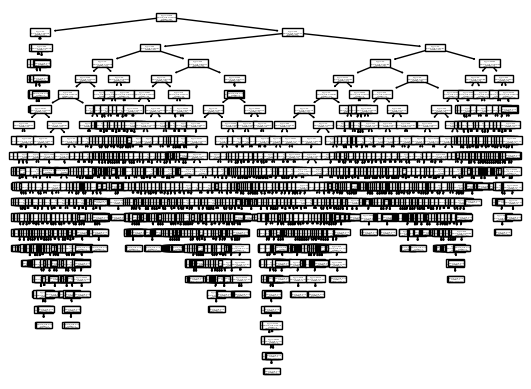

In [21]:
import matplotlib.pyplot as plt
from sklearn import tree
tree.plot_tree(grid.best_estimator_)
plt.show

In [23]:
table=pd.DataFrame.from_dict(re)
table

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_features,param_splitter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.010694,0.004470,0.007914,0.002038,squared_error,sqrt,random,"{'criterion': 'squared_error', 'max_features':...",0.642908,0.399699,0.591843,0.590801,0.530737,0.551198,0.083668,14
1,0.016565,0.004953,0.006889,0.001190,squared_error,sqrt,best,"{'criterion': 'squared_error', 'max_features':...",0.707110,0.565097,0.562403,0.637199,0.528917,0.600145,0.064095,6
2,0.010563,0.002033,0.005846,0.000745,squared_error,log2,random,"{'criterion': 'squared_error', 'max_features':...",0.599911,0.569846,0.571177,0.620373,0.632935,0.598848,0.025429,7
3,0.008981,0.000929,0.006197,0.001486,squared_error,log2,best,"{'criterion': 'squared_error', 'max_features':...",0.745486,0.604026,0.699700,0.566239,0.628077,0.648706,0.065099,3
4,0.009588,0.002226,0.005281,0.000784,friedman_mse,sqrt,random,"{'criterion': 'friedman_mse', 'max_features': ...",0.583493,0.689786,0.443968,0.461940,0.600468,0.555931,0.091684,13
5,0.009141,0.001316,0.004556,0.000423,friedman_mse,sqrt,best,"{'criterion': 'friedman_mse', 'max_features': ...",0.745241,0.115967,0.630202,0.591138,0.562933,0.529096,0.215690,15
6,0.006619,0.001078,0.004229,0.000653,friedman_mse,log2,random,"{'criterion': 'friedman_mse', 'max_features': ...",0.667696,0.568655,0.587187,0.560658,0.690448,0.614929,0.053561,4
7,0.007418,0.000524,0.004559,0.000315,friedman_mse,log2,best,"{'criterion': 'friedman_mse', 'max_features': ...",0.697423,0.521262,0.608110,0.588780,0.651095,0.613334,0.059337,5
8,0.016680,0.001735,0.004342,0.000662,absolute_error,sqrt,random,"{'criterion': 'absolute_error', 'max_features'...",0.639026,0.584634,0.255659,0.518012,0.628017,0.525070,0.141254,16
9,0.020788,0.000214,0.004453,0.000529,absolute_error,sqrt,best,"{'criterion': 'absolute_error', 'max_features'...",0.662398,0.584884,0.626689,0.320905,0.632919,0.565559,0.124805,11


In [24]:
age=int(input("Enter your age: "))
bmi = float(input("Enter your BMI: "))
children = int(input("Enter number of children: "))
sex = input("Enter your sex (M/F): ")
smoker = input("Are you a smoker? (Y/N): ")
sex_male = 1 if sex == "M" else 0
smoker_yes = 1 if smoker == "Y" else 0

Enter your age:  28
Enter your BMI:  28
Enter number of children:  0
Enter your sex (M/F):  M
Are you a smoker? (Y/N):  Y


In [25]:
Future_Prediction=grid.predict([[age,bmi,children,sex_male,smoker_yes]])
print("Future_Prediction={}".format(Future_Prediction))

Future_Prediction=[34672.1472]


C:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
